In [246]:
import numpy as np
import pyomo.environ as pyo
from pyomo.environ import SolverFactory
import matplotlib.pyplot as plt

In [409]:
grid = np.zeros((3,3))
grid[0,1] = 1
grid[1,1] = 1
grid[2,1] = 1
grid[1,2] = 1
print(grid)

origem = (0, 0)
destino = (2, 2)


[[0. 1. 0.]
 [0. 1. 1.]
 [0. 1. 0.]]


In [78]:
vizinhos = {}
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        vizinho_viaveis = []
        # print(f"Vizinhos de ({i}, {j}):")
        cima = (i-1, j)
        baixo = (i+1, j)
        esquerda = (i, j-1)
        direita = (i, j+1)
        vizinho= [cima, baixo, esquerda, direita]
        for v in vizinho:
            # print(v[0], v[1])
            if v[0] >=0 and v[0] < grid.shape[0] and v[1] >= 0 and v[1] < grid.shape[1]:
                vizinho_viaveis.append(v)               
        vizinhos[(i, j)] = vizinho_viaveis

for k in vizinhos:
    print(k, vizinhos[k])

(0, 0) [(1, 0), (0, 1)]
(0, 1) [(1, 1), (0, 0), (0, 2)]
(0, 2) [(1, 2), (0, 1)]
(1, 0) [(0, 0), (2, 0), (1, 1)]
(1, 1) [(0, 1), (2, 1), (1, 0), (1, 2)]
(1, 2) [(0, 2), (2, 2), (1, 1)]
(2, 0) [(1, 0), (2, 1)]
(2, 1) [(1, 1), (2, 0), (2, 2)]
(2, 2) [(1, 2), (2, 1)]


In [239]:
for l,m in vizinhos[0,0]:
    print(l,m)

1 0
0 1


In [162]:
# criar os arcos do grafo
custo_passo = 1
arcos = []
arcos_custo = {}
keys = list(vizinhos.keys())
for i,(j,k) in enumerate(vizinhos.items()):
    # print(i, j, k)
    for jk in k:
        # print(f"Arco: {j} -> {jk}")
        
        soma = grid[jk[0], jk[1]] + grid[j[0], j[1]] + custo_passo
        arcos_custo[(j, jk)] = soma
        arcos.append((j, jk))

In [154]:
grid

array([[0., 1., 0.],
       [0., 1., 1.],
       [0., 1., 0.]])

In [166]:
arcos_custo[(0,0),(0,1)]

np.float64(2.0)

In [155]:
arcos

[((0, 0), (1, 0)),
 ((0, 0), (0, 1)),
 ((0, 1), (1, 1)),
 ((0, 1), (0, 0)),
 ((0, 1), (0, 2)),
 ((0, 2), (1, 2)),
 ((0, 2), (0, 1)),
 ((1, 0), (0, 0)),
 ((1, 0), (2, 0)),
 ((1, 0), (1, 1)),
 ((1, 1), (0, 1)),
 ((1, 1), (2, 1)),
 ((1, 1), (1, 0)),
 ((1, 1), (1, 2)),
 ((1, 2), (0, 2)),
 ((1, 2), (2, 2)),
 ((1, 2), (1, 1)),
 ((2, 0), (1, 0)),
 ((2, 0), (2, 1)),
 ((2, 1), (1, 1)),
 ((2, 1), (2, 0)),
 ((2, 1), (2, 2)),
 ((2, 2), (1, 2)),
 ((2, 2), (2, 1))]

In [122]:
matriz_soma = {}
for k in keys:
    matriz_soma[k] = 0

In [177]:
matriz_soma[(0,0)]= -1
matriz_soma[(2,2)]= 1
matriz_soma

{(0, 0): -1,
 (0, 1): 0,
 (0, 2): 0,
 (1, 0): 0,
 (1, 1): 0,
 (1, 2): 0,
 (2, 0): 0,
 (2, 1): 0,
 (2, 2): 1}

In [221]:
keys

[(0, 0), (0, 1), (0, 2), (1, 0), (1, 1), (1, 2), (2, 0), (2, 1), (2, 2)]

In [189]:
model = pyo.ConcreteModel()

model.k = pyo.Set(initialize=keys)
model.arcos_key = pyo.Set(initialize=list(arcos_custo.keys()))
model.arcos_custo = pyo.Param(model.arcos_key, initialize=arcos_custo)
model.matriz_s = pyo.Param(model.k, initialize=matriz_soma)
model.x = pyo.Var(model.arcos_key, domain=pyo.Binary)

In [210]:
model.pprint()

2 Set Declarations
    arcos_key : Size=1, Index=None, Ordered=Insertion
        Key  : Dimen : Domain : Size : Members
        None :     4 :    Any :   24 : {(0, 0, 1, 0), (0, 0, 0, 1), (0, 1, 1, 1), (0, 1, 0, 0), (0, 1, 0, 2), (0, 2, 1, 2), (0, 2, 0, 1), (1, 0, 0, 0), (1, 0, 2, 0), (1, 0, 1, 1), (1, 1, 0, 1), (1, 1, 2, 1), (1, 1, 1, 0), (1, 1, 1, 2), (1, 2, 0, 2), (1, 2, 2, 2), (1, 2, 1, 1), (2, 0, 1, 0), (2, 0, 2, 1), (2, 1, 1, 1), (2, 1, 2, 0), (2, 1, 2, 2), (2, 2, 1, 2), (2, 2, 2, 1)}
    k : Size=1, Index=None, Ordered=Insertion
        Key  : Dimen : Domain : Size : Members
        None :     2 :    Any :    9 : {(0, 0), (0, 1), (0, 2), (1, 0), (1, 1), (1, 2), (2, 0), (2, 1), (2, 2)}

2 Param Declarations
    arcos_custo : Size=24, Index=arcos_key, Domain=Any, Default=None, Mutable=False
        Key          : Value
        (0, 0, 0, 1) :   2.0
        (0, 0, 1, 0) :   1.0
        (0, 1, 0, 0) :   2.0
        (0, 1, 0, 2) :   2.0
        (0, 1, 1, 1) :   3.0
        (0, 2, 0, 1

In [242]:
model.matriz_s[0,0]

-1

In [220]:
for (i,j,k,l) in model.arcos_key.value:
    print((i,j),(k,l))

retrieve the values in a finite set.  (deprecated in 5.7) (called from
C:\Users\Pichau\AppData\Local\Temp\ipykernel_18356\3084306409.py:1)
(1, 2) (1, 1)
(1, 1) (1, 2)
(2, 1) (2, 0)
(1, 0) (0, 0)
(1, 2) (0, 2)
(2, 1) (1, 1)
(1, 0) (2, 0)
(1, 2) (2, 2)
(2, 0) (1, 0)
(0, 0) (0, 1)
(0, 0) (1, 0)
(2, 1) (2, 2)
(1, 0) (1, 1)
(0, 1) (0, 0)
(0, 1) (1, 1)
(0, 2) (0, 1)
(1, 1) (1, 0)
(2, 0) (2, 1)
(0, 2) (1, 2)
(2, 2) (2, 1)
(1, 1) (0, 1)
(0, 1) (0, 2)
(2, 2) (1, 2)
(1, 1) (2, 1)


In [204]:
#Função objetivo

def func_obj(model):
    return sum(model.arcos_custo[a] * model.x[a] for a in model.arcos_key)
model.obj = pyo.Objective(rule=func_obj, sense=pyo.minimize)

'pyomo.core.base.objective.ScalarObjective'>) on block unknown with a new
Component (type=<class 'pyomo.core.base.objective.AbstractScalarObjective'>).
This is usually indicative of a modelling error. To avoid this warning, use
block.del_component() and block.add_component().


ValueError: too many values to unpack (expected 2)

In [225]:
for i,j in model.k:
    print((i,j))

(0, 0)
(0, 1)
(0, 2)
(1, 0)
(1, 1)
(1, 2)
(2, 0)
(2, 1)
(2, 2)


In [245]:
# Restrição balanço

def func_balanco(model,i,j):
    #tudo que entra para cada i-J menos tudo que sai de cada J tem que ser igual a matriz
    entra = sum(model.x[l,m,i,j] for l,m in vizinhos[i,j])
    sai = sum(model.x[i,j,l,m,] for l,m in vizinhos[i,j])
    return entra-sai == model.matriz_s[i,j]

model.balanco = pyo.Constraint(model.k, rule=func_balanco)

'pyomo.core.base.constraint.IndexedConstraint'>) on block unknown with a new
Component (type=<class 'pyomo.core.base.constraint.IndexedConstraint'>). This
is usually indicative of a modelling error. To avoid this warning, use
block.del_component() and block.add_component().


In [247]:
opt = SolverFactory('cplex', executable='C:\\Program Files\\IBM\\ILOG\\CPLEX_Studio_Community222\\cplex\\bin\\x64_win64\\cplex.exe')
res = opt.solve(model)

In [358]:
valores = []
for s in model.x:
   
    print(s,":",pyo.value(model.x[s]))
valores = [s for s in model.x if pyo.value(model.x[s])>0]

(0, 0, 1, 0) : 1.0
(0, 0, 0, 1) : 0.0
(0, 1, 1, 1) : 0.0
(0, 1, 0, 0) : 0.0
(0, 1, 0, 2) : 0.0
(0, 2, 1, 2) : 0.0
(0, 2, 0, 1) : 0.0
(1, 0, 0, 0) : 0.0
(1, 0, 2, 0) : 1.0
(1, 0, 1, 1) : 0.0
(1, 1, 0, 1) : 0.0
(1, 1, 2, 1) : 0.0
(1, 1, 1, 0) : 0.0
(1, 1, 1, 2) : 0.0
(1, 2, 0, 2) : 0.0
(1, 2, 2, 2) : 0.0
(1, 2, 1, 1) : 0.0
(2, 0, 1, 0) : 0.0
(2, 0, 2, 1) : 1.0
(2, 1, 1, 1) : 0.0
(2, 1, 2, 0) : 0.0
(2, 1, 2, 2) : 1.0
(2, 2, 1, 2) : 0.0
(2, 2, 2, 1) : 0.0


In [362]:
for a,b,c,d in valores:
    print(a,b,c,d)

0 0 1 0
1 0 2 0
2 0 2 1
2 1 2 2


In [365]:
grid

array([[0., 1., 0.],
       [0., 1., 1.],
       [0., 1., 0.]])

In [ ]:
grid

array([0., 1., 0.])

[[0. 1. 0.]
 [0. 1. 1.]
 [0. 1. 0.]]
(0, 0) -> (1, 0)
(1, 0) -> (2, 0)
(2, 0) -> (2, 1)
(2, 1) -> (2, 2)


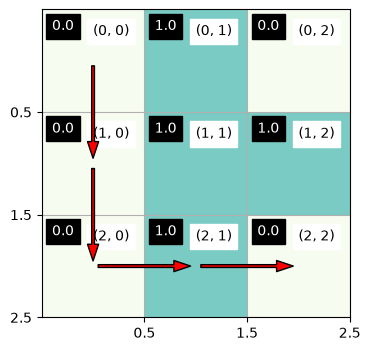

In [495]:
fig, ax = plt.subplots(figsize=(4,4))
print(grid)
ax.imshow(grid,cmap='GnBu',vmin=0,vmax=2)
ax.grid(True)
ax.set_xticks(np.arange(0.5,3,1))
ax.set_yticks(np.arange(0.5,3,1))
# ax.invert_xaxis()  
# ax.invert_yaxis()  

for (i,j) in keys:

    # ax.text(j,i,grid[j,i],color='white',backgroundcolor='black')
    ax.text(j-0.4,i-0.3,grid[i,j],color='white',backgroundcolor='black')
    ax.text(j,i-0.25,(i,j),color='black',backgroundcolor='white',alpha=1)

for a,b,c,d in valores:
    print((a,b),"->",(c,d))
    ax.annotate("",xy=(d,c),xytext=(b,a),arrowprops=dict(facecolor='red', shrink=0.05, width=2, headwidth=8))

plt.show()